In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr
from scipy.spatial.distance import euclidean, cdist

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from skimage.filters import gaussian, median

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20251017_154009.log


In [2]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 16
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), 1e-12)
camera_parameters["readnoise"] = np.full((image_size, image_size), 1e-12)
camera_parameters["rqe"] = np.full((image_size, image_size), 1.0)
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [3]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
dichroic_515_mirror = "semrock-di03-r514-t1-25x36"
nilered_filter = "semrock-ff01-650-200"
shortpass_filter = "semrock-bsp01-785r"
longpass_filter_515 = "semrock-ff01-515-lp"

filters = [nilered_filter, dichroic_515_mirror, longpass_filter_515]
filter_spectra = S_F.get_dye_or_filter_data(
    names=filters, wavelength=wavelength, dye_or_filter=False
)

In [4]:
dye = ["Nile Red"]

In [5]:
dye_spectrum = S_F.get_dye_or_filter_data(names=dye, wavelength=wavelength)
error = np.sqrt(dye_spectrum)

In [6]:
result, fitted_spectrum = S_F.spectral_fit_dye(dye_spectrum, wavelength, 
                                               model="skew-gaussian",
                                               weights=error,
                                               display=True)

In [7]:
result.x

array([  1.76625826e+02,   2.00736234e+00,   1.63009367e-01,
        -1.56451824e+00])

In [8]:
S_F.wavelength_to_energy(result.x[1])

617.64732583535874

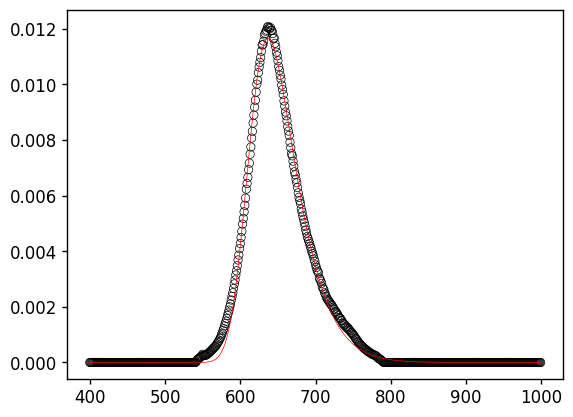

In [9]:
plt.scatter(wavelength, dye_spectrum.T, lw=0.5, color='black', facecolors="none")
plt.plot(wavelength, fitted_spectrum, lw=0.5, color='red')

In [10]:
S_F.wavelength_to_energy(result.x[1])

617.64732583535874

In [11]:
result.x[1:]

array([ 2.00736234,  0.16300937, -1.56451824])

In [12]:
# from https://www.sciencedirect.com/science/article/pii/0003269787901576
dielectric_constant = np.array([80, 64, 58, 44 ,37, 27, 34, 44, 24, 18, 11, 18, 38, 37, 21])
emission = np.array([665, 657, 655, 653, 652, 644, 642, 635, 635, 633, 633, 628, 627, 625, 615])

In [13]:
eV = S_F.wavelength_to_energy(emission)

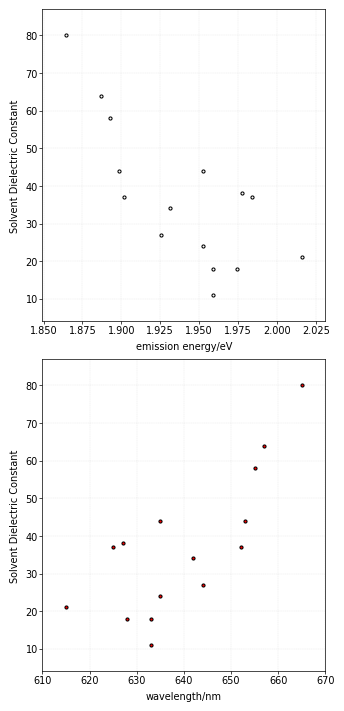

In [14]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1,1])

axs[0] = plotter.scatter_plot(axs[0], eV, dielectric_constant,
                          xaxislabel='emission energy/eV',
                          yaxislabel='Solvent Dielectric Constant')

axs[1] = plotter.scatter_plot(axs[1], emission, dielectric_constant, facecolor='red',
                          xaxislabel='wavelength/nm', yaxislabel='Solvent Dielectric Constant')

In [15]:
from src import NileRedFunctions

NR_F = NileRedFunctions.NileRed_Functions()

In [ ]:
n_photon_space = np.logspace(np.log10(500), np.log10(20000), 25)

NR_F.simulate_wavelength_precision(
      save_folder="/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting",
      wavelength_range=(560, 620),
      wavelength_step=5,
      photon_counts=n_photon_space,
      filter_names=filters,
      n_bootstrap=10000,
      image_size = 16,
      background_photons = 40,
      camera_parameters=camera_parameters,
      verbose=False,
      use_tqdm=False,
  )

Sorting appended HDF5 file by frame: wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
  Read 20,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
Sorting appended HDF5 file by frame: wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
  Read 30,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
Sorting appended HDF5 file by frame: wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
  Read 40,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
Sorting appended HDF5 file by frame: wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
  Read 50,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
Sorting appended HDF5 file by frame: wl5

In [60]:
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting'
files_650 = H_F.file_search(folder, '.h5', 'wl585')
files_650_truth = H_F.file_search(folder, '.csv', 'wl585')

In [61]:
files_650

['/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting/wl585_LM_method_simulated_NileRed_585nm_rawresults.h5']

In [62]:
data_650 = pd.read_hdf(files_650[0])

In [63]:
np.mean(data_650[data_650['photon_level'] == 24]['wl_fit'])

580.79172098750394

In [50]:
meanval = np.nanmean(data_650['A_B'].to_numpy())
stdval = np.nanstd(data_650['A_B'].to_numpy())
meanerrval = np.nanmean(data_650['A_B_err'].to_numpy())
stderrval = np.nanstd(data_650['A_B_err'].to_numpy())

In [51]:
stderrval

2.0912344

In [52]:
files_650_truth

['/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting/wl620_LM_fitting_smoothingfunction_Gaussian_Smoother_smoothingextent_0001p5_simulated_NileRed_620nm_69_pixelsize_1p49_NA_40_background_RMSE_mean_bootstrapping.csv',
 '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting/wl620_LM_fitting_smoothingfunction_Gaussian_Smoother_smoothingextent_0001p5_simulated_NileRed_620nm_69_pixelsize_1p49_NA_40_background_RMSE_std_bootstrapping.csv',
 '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting/wl620_LM_method_simulated_NileRed_620nm_fittesting_input_groundtruthpositions.csv',
 '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting/wl620_LM_method_simulated_NileRed_620nm_fittesting_input_parameters.csv',
 '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting/wl620_LM_method_simulated_NileRed_620nm_pho

In [53]:
gtruth = pl.read_csv(files_650_truth[-2])

In [54]:
gtruth

xc,yc,s_x,s_y,bg_B,bg_G,bg_R,A_B,A_G,A_R
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8.0,8.0,1.428183,1.428183,13.333333,13.333333,13.333333,0.040315,0.223527,0.736159


In [45]:
files_650[-1]

'/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting/wl650_LM_method_simulated_NileRed_650nm_00020000p0_fittesting_rawresults.parquet'

In [46]:
files_650_truth[-1]

'/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting/wl650_LM_method_simulated_NileRed_650nm_fittesting_input_parameters.csv'

In [48]:
data_650

xc,yc,s_x,s_y,bg_B,bg_G,bg_R,A_B,A_G,A_R,chi_sqr,frame,xc_err,yc_err,s_x_err,s_y_err,bg_B_err,bg_G_err,bg_R_err,A_B_err,A_G_err,A_R_err,photons,background_photons,wl_fit,wl_fit_err
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64
7.789514,7.429982,1.473063,1.493755,0.348647,0.327646,0.323707,0.059458,0.221254,0.719288,0.968145,0.0,0.021255,0.021134,0.020534,0.019031,0.01502,0.010604,0.015089,0.007483,0.006564,0.01072,11977.547852,34.629017,null,null
8.713671,8.450886,1.50355,1.505186,0.320986,0.307005,0.372009,0.050864,0.226261,0.722874,1.020287,1.0,0.022275,0.022071,0.01969,0.020514,0.014858,0.010584,0.015074,0.00745,0.006806,0.011113,11892.113281,36.057533,null,null
7.189024,8.05025,1.53009,1.521604,0.333563,0.336084,0.330352,0.05017,0.228591,0.721239,1.041213,2.0,0.022897,0.022485,0.020032,0.021872,0.015095,0.010663,0.015215,0.00762,0.006936,0.011246,12099.40918,36.877254,null,null
7.207654,8.392756,1.454894,1.503094,0.334593,0.337339,0.328068,0.067026,0.22883,0.704144,0.946586,3.0,0.021583,0.020803,0.018915,0.019716,0.014359,0.010215,0.014667,0.007635,0.006513,0.010499,12234.701172,36.601856,null,null
7.660532,8.941177,1.457836,1.492189,0.344765,0.328989,0.326245,0.048508,0.228041,0.723451,0.853199,4.0,0.019834,0.019716,0.018674,0.016768,0.01374,0.009738,0.013961,0.006826,0.006167,0.009969,12202.503906,35.874588,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
7.713909,7.477738,1.496148,1.55293,0.350956,0.330996,0.318048,0.054206,0.226307,0.719486,0.922298,9995.0,0.021421,0.02095,0.020252,0.019125,0.014406,0.010241,0.014654,0.007078,0.006445,0.01052,12125.239258,35.492989,null,null
7.237924,8.052576,1.515272,1.487507,0.328788,0.334581,0.336631,0.057567,0.228207,0.714227,0.888562,9996.0,0.020328,0.020086,0.017781,0.01965,0.014219,0.01009,0.014423,0.006988,0.006215,0.010086,12442.407227,35.239201,null,null
8.214128,7.032009,1.459552,1.520462,0.343533,0.335415,0.321052,0.053798,0.218091,0.728111,0.849916,9997.0,0.019914,0.019705,0.019148,0.016649,0.013644,0.009672,0.013848,0.006991,0.006123,0.009981,12203.019531,36.358055,null,null
